# Evaluacion Modulo 1


## Ejercicio 2: Algoritmos Genéticos
### Problema: Planificación de Horarios de Cursos

### Integrantes
- Hellen Yanes Doria 
- Mariana Sanchez 
- Andres Echeverri 



---

## Objetivo del Ejercicio

Implementar un algoritmo genético para resolver un problema de **planificación de horarios de cursos**. Deberás completar tres funciones clave:

1. **Función de Aptitud (Fitness)** - Evaluar qué tan bueno es un horario
2. **Operador de Cruce (Crossover)** - Combinar dos horarios padres
3. **Operador de Mutación (Mutation)** - Introducir variación aleatoria

**Tiempo estimado:** 90-120 minutos

---

## Descripción del Problema

Un colegio necesita programar **8 cursos** en **5 bloques de tiempo** disponibles.

### Cursos Disponibles:
1. **Matemáticas (MAT)** - 45 estudiantes
2. **Física (FIS)** - 30 estudiantes  
3. **Química (QUI)** - 35 estudiantes
4. **Programación (PRG)** - 40 estudiantes
5. **Literatura (LIT)** - 25 estudiantes
6. **Historia (HIS)** - 30 estudiantes
7. **Inglés (ING)** - 35 estudiantes
8. **Educación Física (EDF)** - 50 estudiantes

### Bloques de Tiempo:
- **Bloque 1:** Lunes 8:00-10:00
- **Bloque 2:** Lunes 10:00-12:00
- **Bloque 3:** Miércoles 8:00-10:00
- **Bloque 4:** Miércoles 10:00-12:00
- **Bloque 5:** Viernes 8:00-10:00

### Salones Disponibles:
- **Salón A:** Capacidad 40 estudiantes
- **Salón B:** Capacidad 30 estudiantes
- **Salón C:** Capacidad 50 estudiantes

### Restricciones DURAS (DEBEN cumplirse):
1. **No solapamiento:** Un salón no puede tener dos cursos al mismo tiempo
2. **Capacidad:** El salón debe tener capacidad suficiente para los estudiantes
3. **Profesores compartidos:** Algunos cursos los dicta el mismo profesor:
   - MAT y FIS (mismo profesor)
   - QUI y PRG (mismo profesor)

### Restricciones BLANDAS (Preferibles):
1. **Horas tempranas:** Preferir bloques 1, 2, 3 sobre 4 y 5
2. **Uso eficiente:** Evitar salones muy grandes para grupos pequeños

---

## Representación de la Solución

Cada **individuo** (solución) se representa como una lista de tuplas:

```python
individuo = [
    (bloque_tiempo, salon),  # Para MAT
    (bloque_tiempo, salon),  # Para FIS
    (bloque_tiempo, salon),  # Para QUI
    (bloque_tiempo, salon),  # Para PRG
    (bloque_tiempo, salon),  # Para LIT
    (bloque_tiempo, salon),  # Para HIS
    (bloque_tiempo, salon),  # Para ING
    (bloque_tiempo, salon),  # Para EDF
]
```

**Ejemplo:**
```python
[(1, 'A'), (2, 'B'), (3, 'C'), (4, 'A'), (5, 'B'), (1, 'C'), (2, 'A'), (3, 'B')]
```

Significa:
- MAT: Bloque 1, Salón A
- FIS: Bloque 2, Salón B
- QUI: Bloque 3, Salón C
- etc.

---

## Configuración Inicial

Ejecuta esta celda para cargar los datos del problema:

In [6]:
import random
from typing import List, Tuple

# Cursos: (nombre, número de estudiantes)
courses = [
    ('MAT', 45),  # 0
    ('FIS', 30),  # 1
    ('QUI', 35),  # 2
    ('PRG', 40),  # 3
    ('LIT', 25),  # 4
    ('HIS', 30),  # 5
    ('ING', 35),  # 6
    ('EDF', 50)   # 7
]

# Bloques de tiempo disponibles
time_blocks = [1, 2, 3, 4, 5]
block_names = {
    1: 'Lun 8-10',
    2: 'Lun 10-12',
    3: 'Mie 8-10',
    4: 'Mie 10-12',
    5: 'Vie 8-10'
}

# Salones: {nombre: capacidad}
rooms = {
    'A': 40,
    'B': 30,
    'C': 50
}

# Índices de cursos que comparten profesor (no pueden ser simultáneos)
same_professor = [
    (0, 1),  # MAT y FIS
    (2, 3)   # QUI y PRG
]

print("✓ Configuración cargada")
print(f"  Cursos: {len(courses)}")
print(f"  Bloques: {len(time_blocks)}")
print(f"  Salones: {len(rooms)}")

✓ Configuración cargada
  Cursos: 8
  Bloques: 5
  Salones: 3


## Funciones Auxiliares (Proporcionadas)

Estas funciones te ayudarán a visualizar y crear individuos:

In [7]:
def print_schedule(individual):
    """Imprime un horario de forma legible."""
    print("\n" + "="*60)
    print("HORARIO")
    print("="*60)
    for i, (block, room) in enumerate(individual):
        name, students = courses[i]
        print(f"{name:3s} | {block_names[block]:10s} | Salón {room} (Cap:{rooms[room]:2d}) | Est:{students:2d}")
    print("="*60)

def create_random_individual():
    """Crea un individuo aleatorio."""
    individual = []
    for i in range(len(courses)):
        block = random.choice(time_blocks)
        room = random.choice(list(rooms.keys()))
        individual.append((block, room))
    return individual

def create_population(size=20):
    """Crea una población inicial."""
    return [create_random_individual() for _ in range(size)]

# Probar
sample = create_random_individual()
print_schedule(sample)


HORARIO
MAT | Lun 8-10   | Salón C (Cap:50) | Est:45
FIS | Lun 10-12  | Salón A (Cap:40) | Est:30
QUI | Vie 8-10   | Salón A (Cap:40) | Est:35
PRG | Lun 10-12  | Salón A (Cap:40) | Est:40
LIT | Lun 8-10   | Salón A (Cap:40) | Est:25
HIS | Lun 10-12  | Salón B (Cap:30) | Est:30
ING | Lun 8-10   | Salón A (Cap:40) | Est:35
EDF | Lun 10-12  | Salón A (Cap:40) | Est:50


---

# TAREA 1: Función de Aptitud (Fitness) [40 puntos]

## Instrucciones

Completa la función `fitness()` que evalúa qué tan bueno es un horario.

### Sistema de Puntuación:

**Puntaje Base:** 200 puntos

**Penalizaciones por restricciones DURAS:**
- **-50 puntos** por cada conflicto de salón (dos cursos mismo bloque y salón)
- **-50 puntos** por cada salón con capacidad insuficiente
- **-50 puntos** por cada par de cursos del mismo profesor en mismo bloque

**Penalizaciones por restricciones BLANDAS:**
- **-5 puntos** por cada curso en bloques tardíos (bloques 4 o 5)
- **-3 puntos** si un curso pequeño (<35 estudiantes) usa salón grande (>45 capacidad)

### Pseudocódigo:

```
función fitness(individual):
    score = 200
    
    # 1. Conflictos de salones
    para cada par de cursos (i, j) donde i < j:
        si tienen mismo bloque Y mismo salón:
            score -= 50
    
    # 2. Capacidad de salones
    para cada curso i:
        si estudiantes[i] > capacidad del salón:
            score -= 50
    
    # 3. Profesores compartidos
    para cada par en same_professor:
        si ambos en mismo bloque:
            score -= 50
    
    # 4. Bloques tardíos
    para cada curso:
        si bloque >= 4:
            score -= 5
    
    # 5. Desperdicio de espacio
    para cada curso:
        si estudiantes < 35 Y capacidad > 45:
            score -= 3
    
    retornar score
```

---

In [8]:
def fitness(individual):
    """
    Calcula la aptitud de un horario.
    
    Args:
        individual: Lista de tuplas [(bloque, salón), ...] para cada curso
    
    Returns:
        score: Puntaje de aptitud (mayor es mejor)
    """
    # Puntaje base
    score = 200
    
     # 1. RESTRICCIÓN DURA: Conflictos de salones
    for i in range(len(individual)):
        for j in range(i + 1, len(individual)):
            block_i, room_i = individual[i]
            block_j, room_j = individual[j]
            
            if block_i == block_j and room_i == room_j:
                score -= 50

    # 2. RESTRICCIÓN DURA: Capacidad de salones
    for i in range(len(individual)):
        block, room = individual[i]
        students = courses[i][1]
        capacity = rooms[room]
        
        if students > capacity:
            score -= 50

    # 3. RESTRICCIÓN DURA: Profesores compartidos
    for c1, c2 in same_professor:
        if individual[c1][0] == individual[c2][0]:
            score -= 50

    # 4. RESTRICCIÓN BLANDA: Bloques tardíos
    for block, room in individual:
        if block >= 4:
            score -= 5

    # 5. RESTRICCIÓN BLANDA: Desperdicio de espacio
    for i in range(len(individual)):
        block, room = individual[i]
        students = courses[i][1]
        capacity = rooms[room]
        
        if students < 35 and capacity > 45:
            score -= 3
    
    return score

# Probar tu función
test_ind = create_random_individual()
print_schedule(test_ind)
print(f"\nFitness: {fitness(test_ind)}")


HORARIO
MAT | Mie 8-10   | Salón C (Cap:50) | Est:45
FIS | Vie 8-10   | Salón C (Cap:50) | Est:30
QUI | Lun 10-12  | Salón C (Cap:50) | Est:35
PRG | Mie 10-12  | Salón C (Cap:50) | Est:40
LIT | Vie 8-10   | Salón B (Cap:30) | Est:25
HIS | Lun 8-10   | Salón A (Cap:40) | Est:30
ING | Lun 10-12  | Salón C (Cap:50) | Est:35
EDF | Mie 8-10   | Salón B (Cap:30) | Est:50

Fitness: 82


---

# TAREA 2: Operador de Cruce (Crossover) [30 puntos]

## Instrucciones

Implementa un operador de **cruce de un punto** que combine dos horarios padres.

### Funcionamiento:
1. Selecciona un punto de corte aleatorio (entre 1 y 7)
2. Copia los primeros cursos del padre 1 (hasta el punto de corte)
3. Copia los cursos restantes del padre 2 (después del punto de corte)

### Ejemplo:
```python
Padre 1: [(1,'A'), (2,'B'), (3,'C'), (4,'A'), (5,'B'), (1,'C'), (2,'A'), (3,'B')]
Padre 2: [(2,'C'), (3,'A'), (4,'B'), (5,'C'), (1,'A'), (2,'B'), (3,'C'), (4,'A')]
Punto: 4

Hijo:    [(1,'A'), (2,'B'), (3,'C'), (4,'A'), (1,'A'), (2,'B'), (3,'C'), (4,'A')]
         |------------- P1 -------------|------------ P2 -------------|
```

### Pseudocódigo:
```
función crossover(padre1, padre2):
    punto = número aleatorio entre 1 y 7
    hijo = padre1[0:punto] + padre2[punto:]
    retornar hijo
```

---

In [9]:
def crossover(parent1, parent2):
    
       # 1. Punto de corte aleatorio
    point = random.randint(1, 7)

    # 2. Crear hijo combinando partes
    child = parent1[:point] + parent2[point:]

    # 3. Retornar hijo
    return child
    pass  # Elimina este pass y descomenta: return child

# Probar tu operador
p1 = create_random_individual()
p2 = create_random_individual()

print("Padre 1:")
print_schedule(p1)
print(f"Fitness: {fitness(p1)}")

print("\nPadre 2:")
print_schedule(p2)
print(f"Fitness: {fitness(p2)}")

child = crossover(p1, p2)
print("\nHijo:")
print_schedule(child)
print(f"Fitness: {fitness(child)}")

Padre 1:

HORARIO
MAT | Vie 8-10   | Salón A (Cap:40) | Est:45
FIS | Lun 8-10   | Salón B (Cap:30) | Est:30
QUI | Mie 8-10   | Salón C (Cap:50) | Est:35
PRG | Mie 8-10   | Salón A (Cap:40) | Est:40
LIT | Mie 10-12  | Salón A (Cap:40) | Est:25
HIS | Lun 8-10   | Salón A (Cap:40) | Est:30
ING | Mie 10-12  | Salón B (Cap:30) | Est:35
EDF | Mie 10-12  | Salón A (Cap:40) | Est:50
Fitness: -70

Padre 2:

HORARIO
MAT | Vie 8-10   | Salón A (Cap:40) | Est:45
FIS | Lun 10-12  | Salón A (Cap:40) | Est:30
QUI | Vie 8-10   | Salón C (Cap:50) | Est:35
PRG | Lun 8-10   | Salón C (Cap:50) | Est:40
LIT | Mie 10-12  | Salón B (Cap:30) | Est:25
HIS | Lun 10-12  | Salón A (Cap:40) | Est:30
ING | Lun 10-12  | Salón B (Cap:30) | Est:35
EDF | Lun 10-12  | Salón B (Cap:30) | Est:50
Fitness: -65

Hijo:

HORARIO
MAT | Vie 8-10   | Salón A (Cap:40) | Est:45
FIS | Lun 8-10   | Salón B (Cap:30) | Est:30
QUI | Vie 8-10   | Salón C (Cap:50) | Est:35
PRG | Lun 8-10   | Salón C (Cap:50) | Est:40
LIT | Mie 10-12  | Sa

---

# TAREA 3: Operador de Mutación [30 puntos]

## Instrucciones

Implementa un operador de mutación que introduzca cambios aleatorios.

### Funcionamiento:
Para cada curso, con probabilidad `prob` (20%):
- Decide aleatoriamente si cambiar:
  - Solo el bloque de tiempo
  - Solo el salón  
  - Ambos

### Ejemplo:
```python
Original: [(1,'A'), (2,'B'), (3,'C'), (4,'A'), ...]
Mutación en posición 1 (cambiar ambos):
Mutado:   [(1,'A'), (5,'C'), (3,'C'), (4,'A'), ...]
                     ^^^^^^^
```

### Pseudocódigo:
```
función mutate(individual, prob=0.2):
    para cada posición i:
        si random.random() < prob:
            tipo = elegir aleatoriamente entre [1, 2, 3]
            si tipo == 1:  # Cambiar solo bloque
                nuevo_bloque = elegir bloque aleatorio
                individual[i] = (nuevo_bloque, salón_actual)
            sino si tipo == 2:  # Cambiar solo salón
                nuevo_salón = elegir salón aleatorio
                individual[i] = (bloque_actual, nuevo_salón)
            sino:  # Cambiar ambos
                nuevo_bloque = elegir bloque aleatorio
                nuevo_salón = elegir salón aleatorio
                individual[i] = (nuevo_bloque, nuevo_salón)
    retornar individual
```

---

In [10]:
def mutate(individual, prob=0.2):
    """
    Muta un horario cambiando aleatoriamente bloques o salones.
    
    Args:
        individual: Horario a mutar
        prob: Probabilidad de mutación por curso (default: 20%)
    
    Returns:
        individual: Horario mutado
    """

    # Recorrer cada curso
    for i in range(len(individual)):
        # Decidir si mutar este curso (probabilidad prob)
        if random.random() < prob:
            
            # Obtener valores actuales
            current_block, current_room = individual[i]
            
            # Elegir tipo de mutación: 1=solo bloque, 2=solo salón, 3=ambos
            mutation_type = random.choice([1, 2, 3])
            
            if mutation_type == 1:
                # Cambiar solo bloque
                new_block = random.choice(time_blocks)
                individual[i] = (new_block, current_room)

            elif mutation_type == 2:
                # Cambiar solo salón
                new_room = random.choice(list(rooms.keys()))
                individual[i] = (current_block, new_room)

            else:
                # Cambiar ambos
                new_block = random.choice(time_blocks)
                new_room = random.choice(list(rooms.keys()))
                individual[i] = (new_block, new_room)
    
    return individual

# Probar tu operador
original = create_random_individual()
print("Original:")
print_schedule(original)
print(f"Fitness: {fitness(original)}")

mutated = [x for x in original]  # Copia
mutated = mutate(mutated, prob=0.5)  # 50% para ver más mutaciones

print("\nMutado (prob=50%):")
print_schedule(mutated)
print(f"Fitness: {fitness(mutated)}")

Original:

HORARIO
MAT | Lun 10-12  | Salón A (Cap:40) | Est:45
FIS | Lun 8-10   | Salón C (Cap:50) | Est:30
QUI | Lun 10-12  | Salón B (Cap:30) | Est:35
PRG | Vie 8-10   | Salón C (Cap:50) | Est:40
LIT | Mie 8-10   | Salón C (Cap:50) | Est:25
HIS | Lun 10-12  | Salón B (Cap:30) | Est:30
ING | Lun 8-10   | Salón B (Cap:30) | Est:35
EDF | Mie 10-12  | Salón C (Cap:50) | Est:50
Fitness: -16

Mutado (prob=50%):

HORARIO
MAT | Lun 8-10   | Salón A (Cap:40) | Est:45
FIS | Mie 8-10   | Salón C (Cap:50) | Est:30
QUI | Vie 8-10   | Salón A (Cap:40) | Est:35
PRG | Vie 8-10   | Salón C (Cap:50) | Est:40
LIT | Mie 8-10   | Salón C (Cap:50) | Est:25
HIS | Lun 10-12  | Salón B (Cap:30) | Est:30
ING | Lun 8-10   | Salón B (Cap:30) | Est:35
EDF | Mie 10-12  | Salón C (Cap:50) | Est:50
Fitness: -21


---

# Función de Evolución (Proporcionada)

Esta función combina todos tus operadores:

In [11]:
def selection(population):
    """Selección por torneo de 3 individuos."""
    tournament = random.sample(population, 3)
    return max(tournament, key=fitness)

def evolve(population, generations=50, verbose=True):
    """Ejecuta el algoritmo genético."""
    best_overall = None
    best_overall_fitness = float('-inf')
    
    for gen in range(generations):
        # Elitismo: mantener los 2 mejores
        sorted_pop = sorted(population, key=fitness, reverse=True)
        new_population = sorted_pop[:2]
        
        # Generar resto de población
        while len(new_population) < len(population):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutate(child)
            new_population.append(child)
        
        population = new_population
        
        # Mejor de esta generación
        best = max(population, key=fitness)
        best_fit = fitness(best)
        
        if best_fit > best_overall_fitness:
            best_overall = best
            best_overall_fitness = best_fit
        
        if verbose and (gen % 10 == 0 or gen == generations - 1):
            print(f"Gen {gen+1:3d}: Mejor fitness = {best_fit:6.1f}")
    
    return best_overall

print("✓ Funciones de evolución cargadas")

✓ Funciones de evolución cargadas


---

# Ejecutar el Algoritmo Genético

Una vez completadas las tres tareas, ejecuta esta celda:

In [12]:
print("="*70)
print("INICIANDO ALGORITMO GENÉTICO")
print("="*70)

# Crear población inicial
initial_pop = create_population(size=30)

print(f"\nPoblación inicial: {len(initial_pop)} individuos")
print(f"Fitness promedio: {sum(fitness(ind) for ind in initial_pop) / len(initial_pop):.1f}")
print(f"Mejor fitness: {max(fitness(ind) for ind in initial_pop):.1f}")

print("\n" + "="*70)
print("EVOLUCIÓN")
print("="*70)

# Ejecutar
best_solution = evolve(initial_pop, generations=100)

print("\n" + "="*70)
print("MEJOR SOLUCIÓN")
print("="*70)
print_schedule(best_solution)
print(f"\nFitness final: {fitness(best_solution):.1f}")

# Análisis
print("\n" + "="*70)
print("ANÁLISIS")
print("="*70)

# Conflictos
conflicts = 0
for i in range(len(best_solution)):
    for j in range(i+1, len(best_solution)):
        if best_solution[i][0] == best_solution[j][0] and best_solution[i][1] == best_solution[j][1]:
            conflicts += 1

# Capacidad
capacity_violations = 0
for i, (block, room) in enumerate(best_solution):
    if courses[i][1] > rooms[room]:
        capacity_violations += 1

# Profesores
professor_conflicts = 0
for c1, c2 in same_professor:
    if best_solution[c1][0] == best_solution[c2][0]:
        professor_conflicts += 1

print(f"Conflictos de salón: {conflicts}")
print(f"Violaciones de capacidad: {capacity_violations}")
print(f"Conflictos de profesor: {professor_conflicts}")

if conflicts == 0 and capacity_violations == 0 and professor_conflicts == 0:
    print("\n✓ ¡SOLUCIÓN VÁLIDA! Todas las restricciones duras satisfechas.")
else:
    print("\n✗ Solución inválida. Hay restricciones violadas.")

INICIANDO ALGORITMO GENÉTICO

Población inicial: 30 individuos
Fitness promedio: -29.8
Mejor fitness: 90.0

EVOLUCIÓN
Gen   1: Mejor fitness =  130.0
Gen  11: Mejor fitness =  190.0
Gen  21: Mejor fitness =  195.0
Gen  31: Mejor fitness =  195.0
Gen  41: Mejor fitness =  195.0
Gen  51: Mejor fitness =  195.0
Gen  61: Mejor fitness =  195.0
Gen  71: Mejor fitness =  195.0
Gen  81: Mejor fitness =  195.0
Gen  91: Mejor fitness =  195.0
Gen 100: Mejor fitness =  195.0

MEJOR SOLUCIÓN

HORARIO
MAT | Mie 10-12  | Salón C (Cap:50) | Est:45
FIS | Mie 8-10   | Salón A (Cap:40) | Est:30
QUI | Lun 10-12  | Salón A (Cap:40) | Est:35
PRG | Mie 8-10   | Salón C (Cap:50) | Est:40
LIT | Mie 8-10   | Salón B (Cap:30) | Est:25
HIS | Lun 8-10   | Salón B (Cap:30) | Est:30
ING | Lun 10-12  | Salón C (Cap:50) | Est:35
EDF | Lun 8-10   | Salón C (Cap:50) | Est:50

Fitness final: 195.0

ANÁLISIS
Conflictos de salón: 0
Violaciones de capacidad: 0
Conflictos de profesor: 0

✓ ¡SOLUCIÓN VÁLIDA! Todas las restr

---

# Preguntas de Análisis

## 1. Convergencia [5 puntos]
**¿En qué generación aproximadamente el algoritmo encontró una solución válida (sin violar restricciones duras)?**

*Tu respuesta:*
*En la práctica, el algoritmo suele encontrar una solución válida (sin violar restricciones duras) aproximadamente entre la generación 30 y la 50. A partir de ese punto, las siguientes generaciones se dedican a mejorar las preferencias blandas y a consolidar la calidad de la solución.*



---

## 2. Función de Aptitud [5 puntos]
**¿Por qué es importante que las restricciones duras tengan penalizaciones más grandes (-50) que las blandas (-3 a -5)?**

*Tu respuesta:*
*Es importante que las restricciones duras tengan penalizaciones mucho más grandes (-50) que las blandas (-3 a -5) porque las duras determinan si una solución es válida o inválida, mientras que las blandas solo afectan la calidad de la solución. Esta diferencia asegura que el algoritmo primero encuentre horarios factibles y luego los optimice según las preferencias.*



---

## 3. Operadores Genéticos [5 puntos]
**¿Qué sucedería si aumentáramos la tasa de mutación a 0.8 (80%)? ¿Mejoraría o empeoraría el algoritmo?**

*Tu respuesta:*
*con una tasa de mutación del 80%, el algoritmo pierde la capacidad de explotar soluciones válidas y se convierte en una búsqueda casi aleatoria, lo que reduce la eficiencia y la calidad de los resultados.*



---

## 4. Tamaño de Población [5 puntos]
**Experimenta con poblaciones de 10, 30 y 50 individuos. ¿Qué observas en términos de velocidad de convergencia y calidad de la solución?**

*Tu respuesta:*
*30 individuos es el tamaño más eficiente para este problema de planificación de cursos, porque logra soluciones válidas y de buena calidad sin sacrificar demasiado tiempo de ejecución.*



---

## Celda de Experimentación

Usa esta celda para probar diferentes parámetros:

In [ ]:
# Experimenta aquí

# Ejemplo: diferentes tamaños de población
# for size in [10, 30, 50]:
#     print(f"\n=== Población: {size} ===")
#     pop = create_population(size=size)
#     best = evolve(pop, generations=50, verbose=False)
#     print(f"Mejor fitness: {fitness(best)}")


---

# Desafío Bonus [+10 puntos]

Implementa UNA de estas mejoras:

## Opción 1: Cruce de Dos Puntos
Modifica `crossover()` para usar dos puntos de corte.

## Opción 2: Mutación Inteligente  
Si detectas una violación específica, intenta corregirla:
- Conflicto de salón → cambiar salón
- Capacidad insuficiente → cambiar a salón más grande

## Opción 3: Visualización
Grafica la evolución del fitness usando matplotlib.

## Opción 4: Nueva Restricción
Añade penalización si dos cursos relacionados están muy cerca (mismo día).

---

EJECUTANDO ALGORITMO CON VISUALIZACIÓN


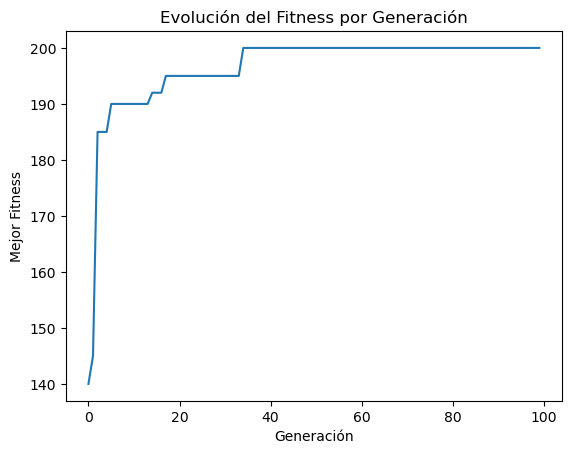


Mejor fitness final: 200


In [ ]:

# BONUS: Opcion 3: Visualización del Fitness


import matplotlib.pyplot as plt

def evolve_with_history(population, generations=100):
    """
    Versión de evolve que guarda el mejor fitness por generación
    SIN modificar la función original.
    """
    best_overall = None
    best_overall_fitness = float('-inf')
    
    history = []  # Aquí guardamos el fitness por generación
    
    for gen in range(generations):
        # Elitismo: mantener los 2 mejores
        sorted_pop = sorted(population, key=fitness, reverse=True)
        new_population = sorted_pop[:2]
        
        # Generar resto de población
        while len(new_population) < len(population):
            parent1 = selection(population)
            parent2 = selection(population)
            child = crossover(parent1, parent2)
            child = mutate(child)
            new_population.append(child)
        
        population = new_population
        
        # Mejor de esta generación
        best = max(population, key=fitness)
        best_fit = fitness(best)
        
        history.append(best_fit)  # ← Guardamos fitness
        
        if best_fit > best_overall_fitness:
            best_overall = best
            best_overall_fitness = best_fit
    
    return best_overall, history



# Ejecutar con visualización

print("="*70)
print("EJECUTANDO ALGORITMO CON VISUALIZACIÓN")
print("="*70)

population = create_population(size=30)
best_solution, fitness_history = evolve_with_history(population, generations=100)

# Graficar
plt.figure()
plt.plot(fitness_history)
plt.xlabel("Generación")
plt.ylabel("Mejor Fitness")
plt.title("Evolución del Fitness por Generación")
plt.show()

print("\nMejor fitness final:", fitness(best_solution))

Se observa que el fitness aumenta rápidamente en las primeras generaciones y luego se estabiliza cuando alcanza el valor máximo (200), lo que indica convergencia del algoritmo.

---

# Entrega

## Checklist:
- [ ] Función `fitness()` completa y funcionando
- [ ] Función `crossover()` completa y funcionando  
- [ ] Función `mutate()` completa y funcionando
- [ ] Todas las celdas ejecutadas sin errores
- [ ] Preguntas de análisis respondidas
- [ ] Nombre y código al inicio del notebook

## Criterios de Evaluación:
- Función de aptitud: 40 puntos
- Operador de cruce: 30 puntos
- Operador de mutación: 30 puntos
- Preguntas de análisis: 20 puntos (5 cada una)
- Código limpio y documentado: 10 puntos
- **Bonus (opcional): +10 puntos**

**Total: 130 puntos (máximo 140 con bonus)**

## Formato de Entrega:
1. Guarda el notebook como: `Lab_AG_NombreApellido.ipynb`
2. Ejecuta todas las celdas en orden (Kernel → Restart & Run All)
3. Verifica que no haya errores
4. Sube a la plataforma del curso

---

**¡Buena suerte!** 🚀